# Day-8 Submission

## Assignment: CIFAR-100 Image Classification

Your task is to apply the concepts and techniques learned in this Fashion-MNIST project to the CIFAR-100 dataset. CIFAR-100 is a dataset consisting of 60,000 32x32 color images in 100 classes, with 600 images per class. There are 50,000 training images and 10,000 test images.

Follow these steps:

1.  **Dataset Setup:**
    *   Load the CIFAR-100 dataset.
    *   Preprocess the data (normalize pixel values, one-hot encode labels). Remember that CIFAR-100 images are 32x32 color images, so the input shape will be different from Fashion-MNIST.
    *   Verify the shapes of the processed data.

2.  **Model Building:**
    *   Adapt the ANN and CNN model architectures for the CIFAR-100 dataset. Consider that CIFAR-100 images are color (3 channels) and have a different resolution (32x32). You might need to adjust the input layer and potentially the number of filters or layers in the CNNs for better performance on a more complex dataset.

3.  **Model Training:**
    *   Train the models using the preprocessed CIFAR-100 training data. Use Early Stopping and Model Checkpointing as implemented before.

4.  **Model Evaluation:**
    *   Evaluate the trained models on the CIFAR-100 test set. Compare their performance using loss and accuracy.
    *   Visualize training history and confusion matrices.

5.  **Prediction Analysis:**
    *   Choose the best performing model and analyze its predictions on the CIFAR-100 test set.

**Goal:** To understand how model complexity and architecture choices impact performance on a more challenging image classification dataset like CIFAR-100.

Table of Contents

1. [Dataset setup documentation](#1-dataset-setup-documentation)
   - [1.1 CIFAR-100 dataset information](#11-cifar-100-dataset-information)
   - [1.2 nImporting libraries](#12-importing-libraries)
   - [1.3 Load the dataset](#13-load-the-dataset)
   - [1.4 Normalize data](#14-normalize-data)
   - [1.5 One-hot encode labels](#15-one-hot-encode-labels)
   - [1.6 Verify dataset shapes](#16-verify-dataset-shapes)
2. [Model Building](#2-model-building)
   - [2.1 CNN Model](#21-cnn-model)
3. [Model Training](#3-model-training)
   - [3.1 Training CNN model](#31-training-cnn-model)
4. [Model Evaluation](#4-model-evaluation)
   - [4.1 Model evaluation (confusion matrix & report)](#41-model-evaluation-confusion-matrix--report)
   - [4.2 Model accuracy and test loss plot](#42-model-accuracy-and-test-loss-plot)
   - [4.3 Predictions](#43-predictions)
5. [Project summary and conclusion](#5-project-summary--conclusion)

# CIFAR-100 Classification Project

## 1. Dataset Setup Documentation

### 1.1 CIFAR-100 dataset information

The CIFAR-100 dataset consists of 60000 32x32 colour images in 100 classes, with 600 images per class. The 100 classes in the CIFAR-100 are grouped into 20 superclasses. Each image comes with a "fine" label (the class to which it belongs) and a "coarse" label (the superclass to which it belongs). There are 50000 training images and 10000 test images.
The meta file contains the label names of each class and superclass.
<br> <br>
Here is the list of the 100 classes in the CIFAR-100:

- **aquatic mammals** → beaver, dolphin, otter, seal, whale
- **fish** → aquarium fish, flatfish, ray, shark, trout
- **flowers** → orchids, poppies, roses, sunflowers, tulips
- **food containers** → bottles, bowls, cans, cups, plates
- **fruit and vegetables** → apples, mushrooms, oranges, pears, sweet peppers
- **household electrical devices** → clock, computer keyboard, lamp, telephone, television
- **household furniture** → bed, chair, couch, table, wardrobe
- **insects** → bee, beetle, butterfly, caterpillar, cockroach
- **large carnivores** → bear, leopard, lion, tiger, wolf
- **large man-made outdoor things** → bridge, castle, house, road, skyscraper
- **large natural outdoor scenes** → cloud, forest, mountain, plain, sea
- **large omnivores and herbivores** → camel, cattle, chimpanzee, elephant, kangaroo
- **medium-sized mammals** → fox, porcupine, possum, raccoon, skunk
- **non-insect invertebrates** → crab, lobster, snail, spider, worm
- **people** → baby, boy, girl, man, woman
- **reptiles** → crocodile, dinosaur, lizard, snake, turtle
- **small mammals** → hamster, mouse, rabbit, shrew, squirrel
- **trees** → maple, oak, palm, pine, willow
- **vehicles 1 (land)** → bicycle, bus, motorcycle, pickup truck, train
- **vehicles 2 (water/air)** → lawn-mower, rocket, streetcar, tank, tractor

In [1]:
cifar100_labels = [
    "apple",
    "aquarium_fish",
    "baby",
    "bear",
    "beaver",
    "bed",
    "bee",
    "beetle",
    "bicycle",
    "bottle",
    "bowl",
    "boy",
    "bridge",
    "bus",
    "butterfly",
    "camel",
    "can",
    "castle",
    "caterpillar",
    "cattle",
    "chair",
    "chimpanzee",
    "clock",
    "cloud",
    "cockroach",
    "couch",
    "crab",
    "crocodile",
    "cup",
    "dinosaur",
    "dolphin",
    "elephant",
    "flatfish",
    "forest",
    "fox",
    "girl",
    "hamster",
    "house",
    "kangaroo",
    "keyboard",
    "lamp",
    "lawn_mower",
    "leopard",
    "lion",
    "lizard",
    "lobster",
    "man",
    "maple",
    "motorcycle",
    "mountain",
    "mouse",
    "mushroom",
    "oak",
    "orange",
    "orchid",
    "otter",
    "palm",
    "pear",
    "pickup_truck",
    "pine",
    "plain",
    "plate",
    "poppy",
    "porcupine",
    "possum",
    "rabbit",
    "raccoon",
    "ray",
    "road",
    "rocket",
    "rose",
    "sea",
    "seal",
    "shark",
    "shrew",
    "skunk",
    "skyscraper",
    "snail",
    "snake",
    "spider",
    "squirrel",
    "streetcar",
    "sunflower",
    "sweet_pepper",
    "table",
    "tank",
    "telephone",
    "television",
    "tiger",
    "tractor",
    "train",
    "trout",
    "tulip",
    "turtle",
    "wardrobe",
    "whale",
    "willow",
    "wolf",
    "woman",
    "worm",
]

### 1.2 Importing libraries

This section imports the essential libraries:
- **Numpy** for numerical operations
- **TensorFlow / Keras** for building and training deep learning models
- **Matplotlib** for visualizations

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

### 1.3 Load the dataset
Load the **CIFAR-100** dataset from keras, splitting it into:
- `cifar100_train_images`, `cifar100_train_labels` -> training set
- `cifar100_test-images`, `cifar100_test_labels` -> test set

In [3]:
(cifar100_train_images, cifar100_train_labels), (
    cifar100_test_images,
    cifar100_test_labels,
) = keras.datasets.cifar100.load_data()

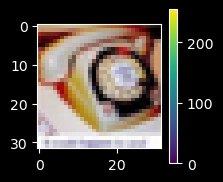

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(cifar100_train_images[5])
plt.colorbar()
plt.show()

In [5]:
cifar100_train_labels[5]

array([86])

### 1.4 Normalize Data
Scale pixel values **from 0-255** to the range **0-1** for faster and more stable training.<br><br>
Example:
- Before - a pixel value could be 200 (let)
- After - 200 / 255 = 0.78

In [6]:
cifar100_train_images = cifar100_train_images / 255.0
cifar100_test_images = cifar100_test_images / 255.0

### 1.5 One-Hot Encode Labels

Convert class labels (1-100) into **one-hot encoded vectors** with 100 outputs classes, required for multi-class classification.

In [7]:
cifar100_train_labels_one_hot = keras.utils.to_categorical(
    cifar100_train_labels, num_classes=100
)
cifar100_test_labels_one_hot = keras.utils.to_categorical(
    cifar100_test_labels, num_classes=100
)

### 1.6 Verify Dataset Shapes
Print the shapes of images and lables after preprocessing to confirm everything is in the expected format.

In [8]:
print("CIFAR-100 Training images shape:", cifar100_train_images.shape)
print("CIFAR-100 Testing images shape:", cifar100_test_images.shape)
print("CIFAR-100 Training labels shape:", cifar100_train_labels.shape)
print("CIFAR-100 Testing labels shape:", cifar100_test_labels.shape)

CIFAR-100 Training images shape: (50000, 32, 32, 3)
CIFAR-100 Testing images shape: (10000, 32, 32, 3)
CIFAR-100 Training labels shape: (50000, 1)
CIFAR-100 Testing labels shape: (10000, 1)


## 2. Model Building

### 2.1 CNN Model
- Conv2D (32, 3x3) + BN -> 896 + 128 params
- Conv2D (32, 3x3) + BN + MaxPool + Dropout -> 9,248 + 128 params
- Conv2D (64, 3x3) + BN -> 18,496 + 256 params
- Conv2D (64, 3x3) + BN + MaxPool + Dropout -> 36,928 + 256 params
- Conv2D (128, 3x3) + BN -> 73,856 + 512 params
- Conv2D (128, 3x3) + BN + MaxPool + Dropout -> 147,584 + 512 params
- Flatten (2048) -> 0 params
- Dense (512, ReLU) + BN + Dropout -> 1,049,088 + 2,048 params
- Dense (128, ReLU) + Dropout -> 65,664 params
- Dense (100, Softmax) -> 12,900

Total params: 1,414,500 params

In [9]:
cnn_model = keras.Sequential(
    [
        keras.Input(shape=(32, 32, 3)),
        keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        keras.layers.BatchNormalization(axis=3),
        keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same"),
        keras.layers.Dropout(0.3),
        keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        keras.layers.BatchNormalization(axis=3),
        keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same"),
        keras.layers.Dropout(0.3),
        keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        keras.layers.BatchNormalization(axis=3),
        keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same"),
        keras.layers.Dropout(0.5),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.25),
        keras.layers.Dense(100, activation="softmax"),
    ]
)

cnn_model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

cnn_model.summary()

2025-09-30 10:28:41.914934: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-09-30 10:28:41.915219: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-09-30 10:28:41.915238: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-09-30 10:28:41.915294: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-30 10:28:41.915462: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,418,500 (5.41 MB)

 Trainable params: 1,416,580 (5.40 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 3. Model Training

### 3.1 Training CNN model
- **Early Stopping**: monitors validation loss, stops if no improvement for 5 epochs, restores best weights. 
- **ModelCheckpoint**: saves best CNN weights (`best_cnn_model_weights.weights.h5`) based on validation loss.
- **Training**:
    - Epochs: upto 30 (early stopping controls actual run)
    - Batch size: 64
    - Validation on test set
    - Callbacks: EarlyStopping + ModelCheckpoint

In [10]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="best_cnn_model_weights.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1,
)

In [11]:
import time

print("Training CNN Model ...")
training_start = time.time()

cnn_history = cnn_model.fit(
    cifar100_train_images,
    cifar100_train_labels_one_hot,
    epochs=50,
    batch_size=128,
    validation_data=(cifar100_test_images, cifar100_test_labels_one_hot),
    callbacks=[early_stopping, model_checkpoint],
)

training_stop = time.time()
print("CNN model training finished.")

training_time = training_stop - training_start
print(f"Training time: {training_time}")

Training CNN Model ...
Epoch 1/50


2025-09-30 10:28:46.162393: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.0345 - loss: 5.2679
Epoch 1: val_loss improved from None to 4.80747, saving model to best_cnn_model_weights.weights.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.0539 - loss: 4.7837 - val_accuracy: 0.0351 - val_loss: 4.8075
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.1031 - loss: 4.1704
Epoch 2: val_loss improved from 4.80747 to 3.53105, saving model to best_cnn_model_weights.weights.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.1147 - loss: 4.0901 - val_accuracy: 0.1736 - val_loss: 3.5311
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.1459 - loss: 3.8053
Epoch 3: val_loss improved from 3.53105 to 3.19018, saving model to best_cnn_model_weights.weights.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.1573 - loss: 3.7336 - val_accuracy: 0.2255 - val_loss: 3.1902
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1949 - loss: 3.4794
Ep

## 4. Model Evaluation

### 4.1 Model Evaluation (Confusion matrix & Report)
- Predict test images (CNN model)
- Convert one-hot labels to integers
- Get predicted labels with `argmax`
- Print confusion matrix & classification report for the model

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


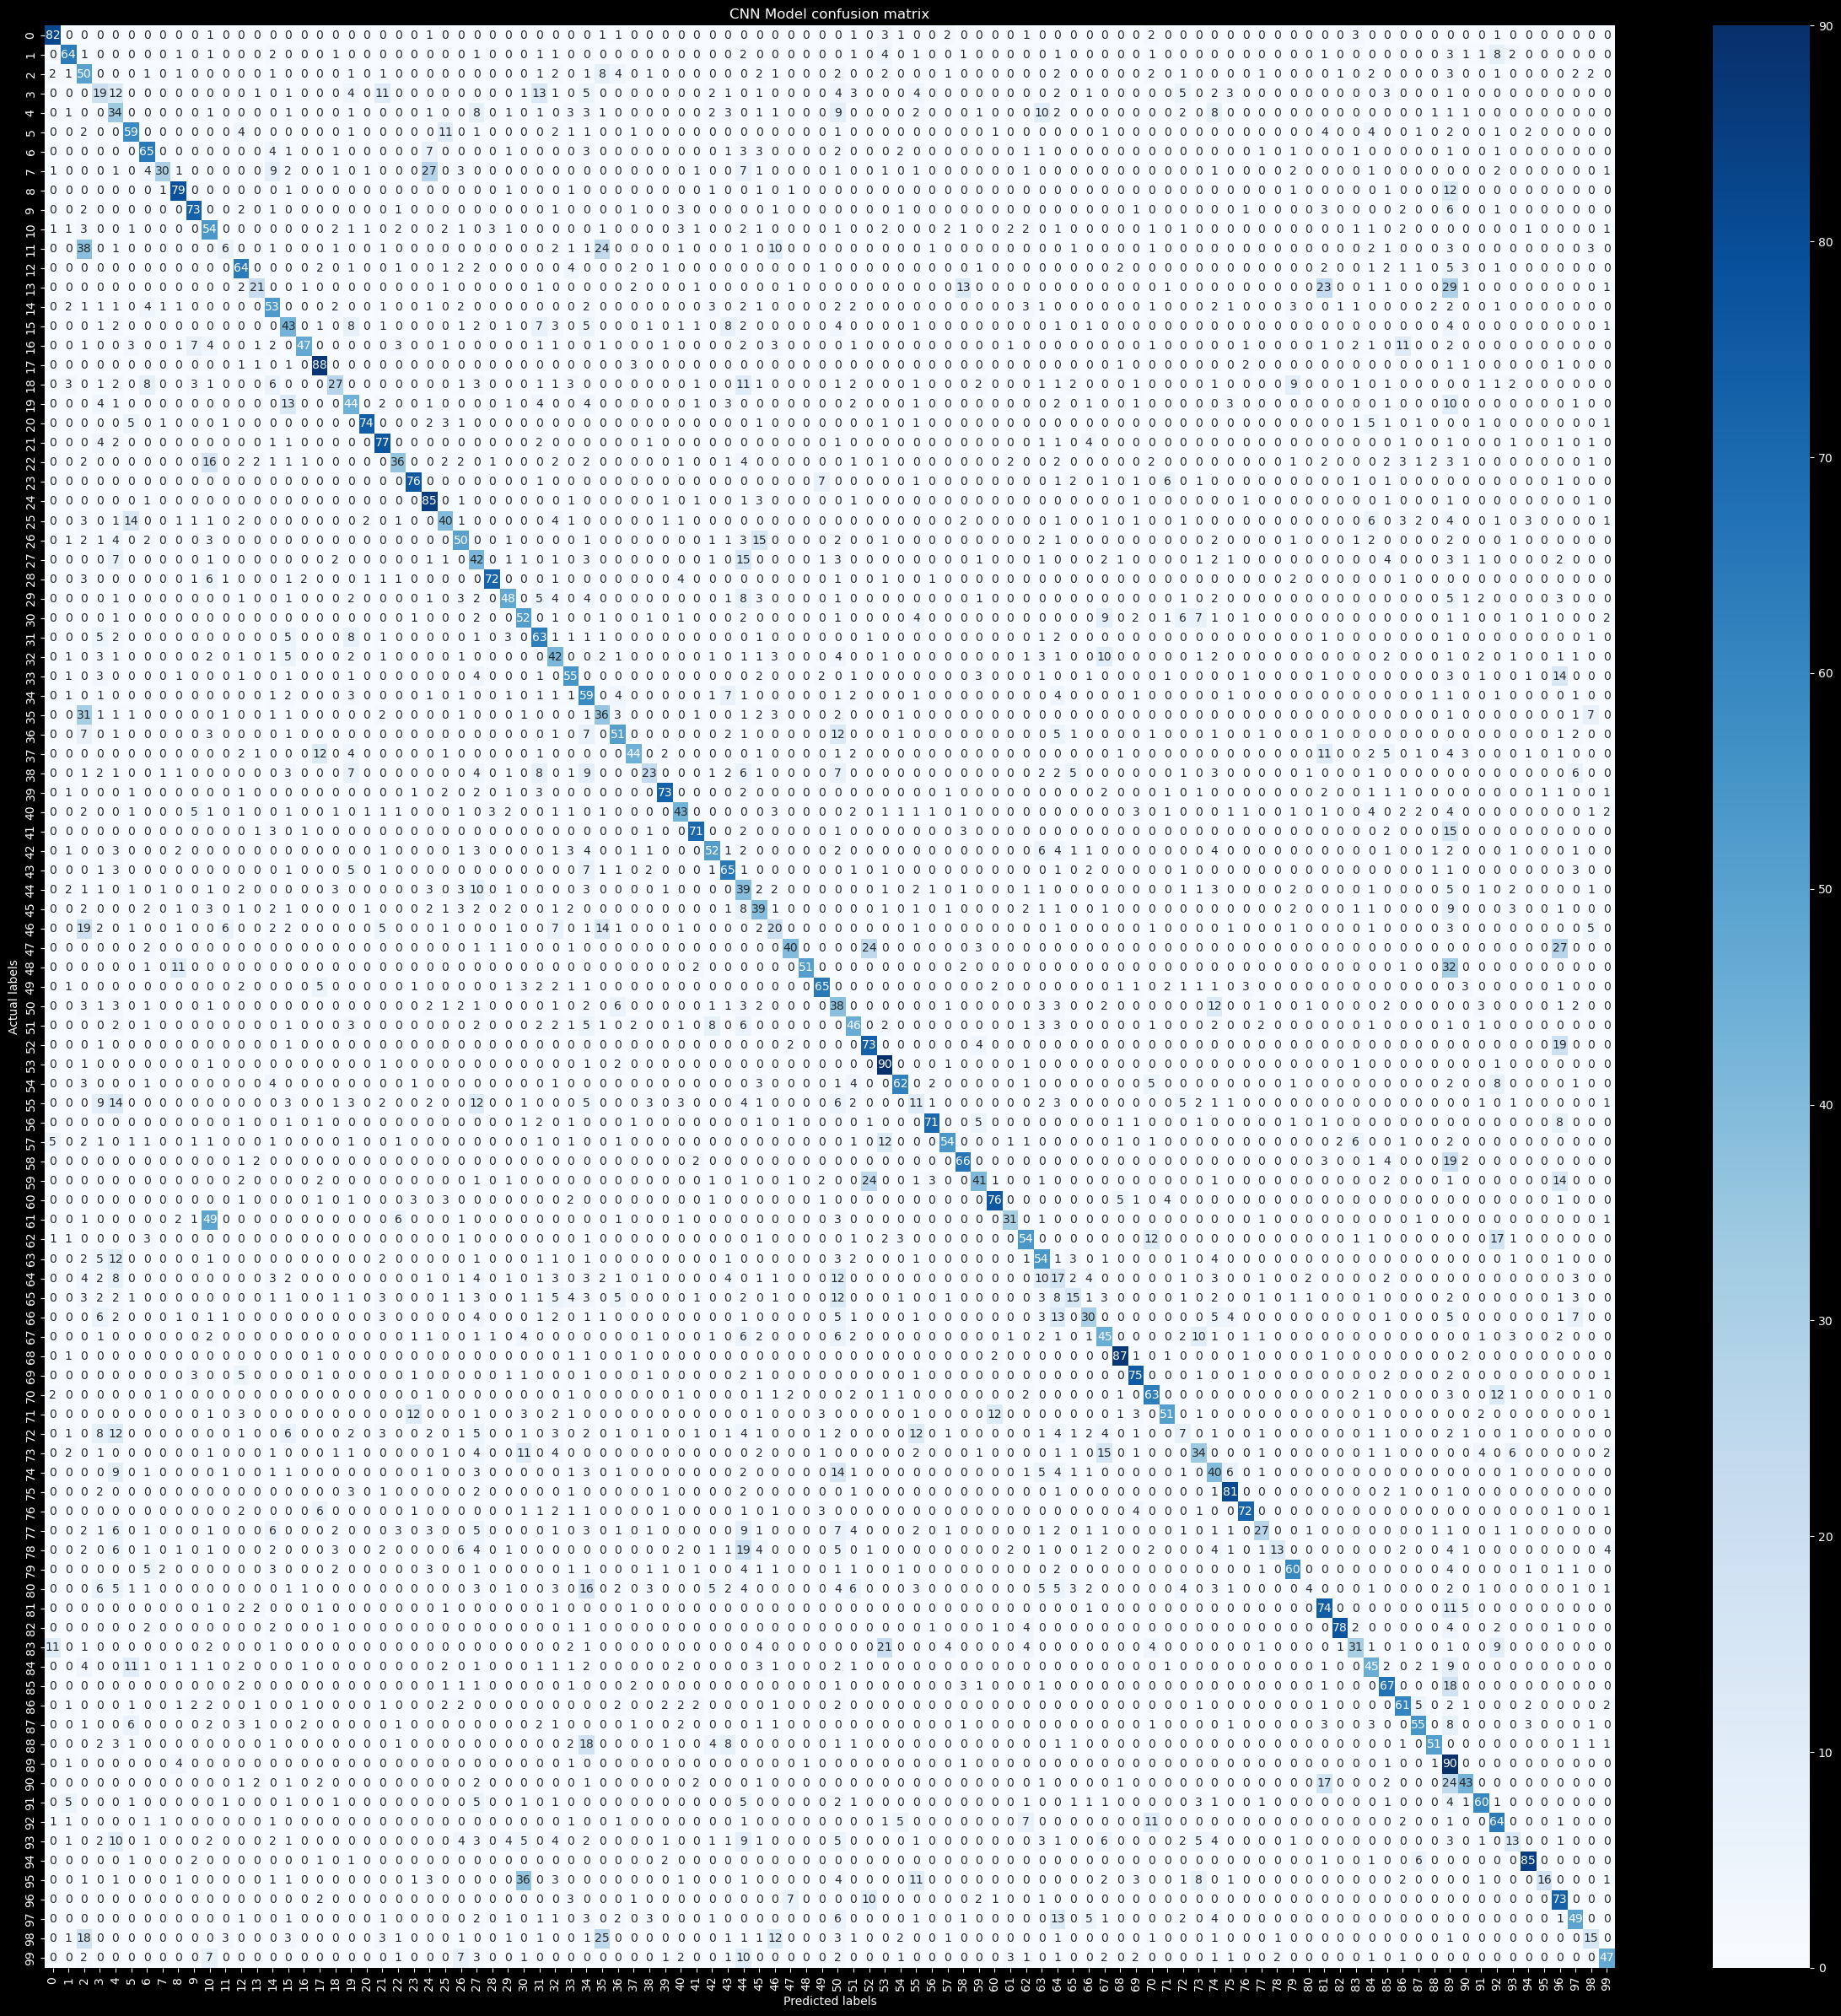

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cnn_model.load_weights("best_cnn_model_weights.weights.h5")

loss_cnn, accuracy_cnn = cnn_model.evaluate(
    cifar100_test_images, cifar100_test_labels_one_hot, verbose=0
)

# prediction
cnn_predictions = cnn_model.predict(cifar100_test_images)

# convert labels
test_labels_int = np.argmax(cifar100_test_labels_one_hot, axis=1)
cnn_predicted_labels = np.argmax(cnn_predictions, axis=1)

# confusion matrix
cm_cnn = confusion_matrix(test_labels_int, cnn_predicted_labels)

# plot of confusion matrix
plt.figure(figsize=(24, 24))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Model confusion matrix")
plt.xlabel("Predicted labels")
plt.ylabel("Actual labels")
plt.tight_layout()
plt.show()

In [13]:
if len(cifar100_test_labels.shape) > 1 and cifar100_test_labels.shape[1] == 100:
    true_labels = np.argmax(cifar100_test_labels, axis=1)
else:
    true_labels = cifar100_test_labels

report = classification_report(
    true_labels,
    cnn_predicted_labels,
    target_names=cifar100_labels,
)

print("----------- CNN Model Performance ------------")
print(report)

----------- CNN Model Performance ------------
               precision    recall  f1-score   support

        apple       0.77      0.82      0.80       100
aquarium_fish       0.67      0.64      0.65       100
         baby       0.23      0.50      0.31       100
         bear       0.19      0.19      0.19       100
       beaver       0.19      0.34      0.25       100
          bed       0.53      0.59      0.56       100
          bee       0.59      0.65      0.62       100
       beetle       0.77      0.30      0.43       100
      bicycle       0.70      0.79      0.74       100
       bottle       0.73      0.73      0.73       100
         bowl       0.31      0.54      0.39       100
          boy       0.29      0.06      0.10       100
       bridge       0.55      0.64      0.59       100
          bus       0.58      0.21      0.31       100
    butterfly       0.44      0.53      0.48       100
        camel       0.37      0.43      0.40       100
          can    

### 4.2 Model Accuracy and test loss plot
- Created a dataframe to store **test loss** and **test accuracy** for CNN model.
- Plotted training history for the model (accuracy & loss vs. epochs).
- Helps compare how models learn and generalize over time.

In [14]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Number of epochs
epochs = np.arange(1, len(cnn_history.history["accuracy"]) + 1)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Model Accuracy", "Model Loss"),
    horizontal_spacing=0.15,
)

# ----- Accuracy -----
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=cnn_history.history["accuracy"],
        mode="lines+markers",
        name="Training Accuracy",
        line=dict(color="magenta", dash="solid"),
        hovertemplate="Epoch %{x}<br>Acc: %{y:.4f}",
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=epochs,
        y=cnn_history.history["val_accuracy"],
        mode="lines+markers",
        name="Validation Accuracy",
        line=dict(color="green", dash="dot"),
        hovertemplate="Epoch %{x}<br>Val Acc: %{y:.4f}",
    ),
    row=1,
    col=1,
)

# ----- Loss -----
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=cnn_history.history["loss"],
        mode="lines+markers",
        name="Training Loss",
        line=dict(color="magenta", dash="solid"),
        hovertemplate="Epoch %{x}<br>Loss: %{y:.4f}",
    ),
    row=1,
    col=2,
)

fig.add_trace(
    go.Scatter(
        x=epochs,
        y=cnn_history.history["val_loss"],
        mode="lines+markers",
        name="Validation Loss",
        line=dict(color="green", dash="dot"),
        hovertemplate="Epoch %{x}<br>Val Loss: %{y:.4f}",
    ),
    row=1,
    col=2,
)

# ----- Layout -----
fig.update_layout(
    title_text="CNN Training Progress: Accuracy & Loss",
    height=500,
    width=1400,
    template="plotly_dark",
    title_x=0.5,
    legend=dict(orientation="h", yanchor="bottom", y=-0.4, xanchor="center", x=0.5),
    font=dict(size=14),
)

fig.update_xaxes(title_text="Epoch", row=1, col=1)
fig.update_xaxes(title_text="Epoch", row=1, col=2)
fig.update_yaxes(title_text="Accuracy", row=1, col=1)
fig.update_yaxes(title_text="Loss", row=1, col=2)

fig.show()

### 4.3 Predictions

This code: 
- Uses the trained **CNN model** to predict on test images.
- Identifies **correctly** and **incorrectly** classified samples.
- Randomly selects 100 correct and 100 incorrect predictions.
- Displays them in a 20x10 grid:
    - ✅ Correct predictions -> **Green title** (only predicted label).
    - ❌ Incorrect predictions -> **Red title** (Predicted vs. True label).

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


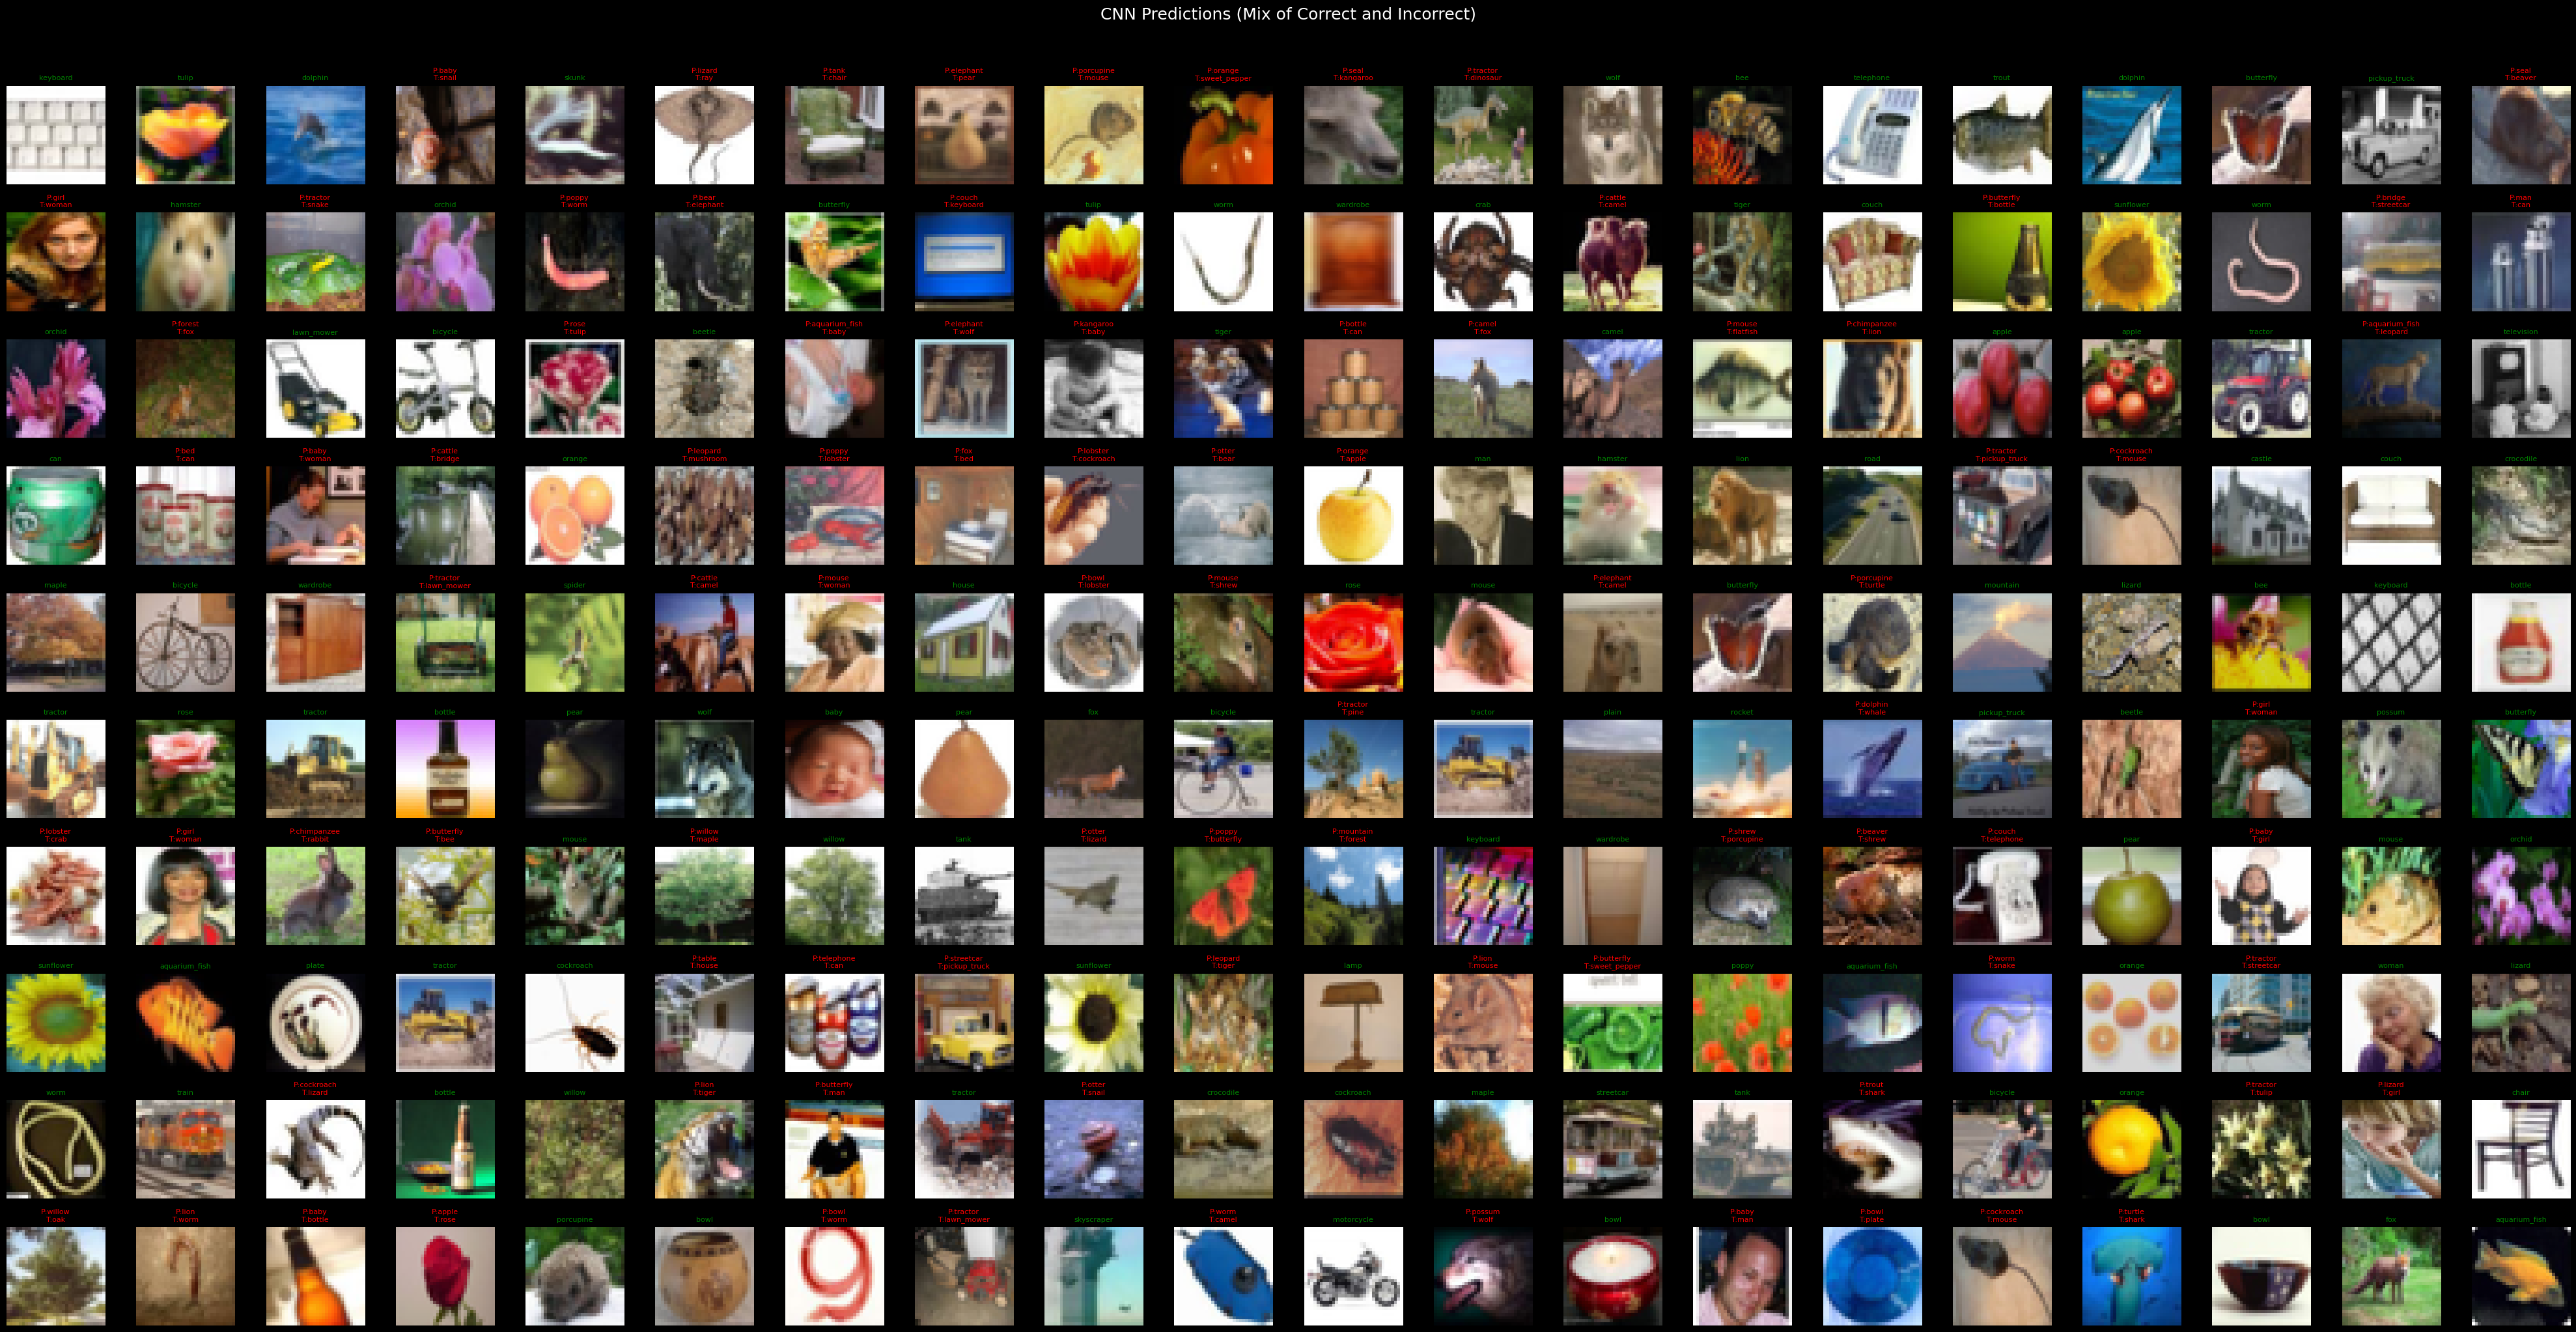

In [15]:
cnn_predictions = cnn_model.predict(cifar100_test_images)
cnn_predicted_labels = np.argmax(cnn_predictions, axis=1)

# find correctly and incorrectly classified images
correctly_classified_indices = np.where(cnn_predicted_labels == cifar100_test_labels)[0]
incorrectly_classified_indices = np.where(cnn_predicted_labels != cifar100_test_labels)[
    0
]

# Define class name for CIFAR-100 dataset (already defined in the beginning of the notebook)
class_names = cifar100_labels

# select a mix of correctly and incorrectly classified images
num_correct_to_show = 100
num_incorrect_to_show = 100

# ensure we don't try to show more images than available
num_correct_to_show = min(num_correct_to_show, len(correctly_classified_indices))
num_incorrect_to_show = min(num_incorrect_to_show, len(incorrectly_classified_indices))

selected_correct_indices = np.random.choice(
    correctly_classified_indices, num_correct_to_show, replace=False
)

selected_incorrect_indices = np.random.choice(
    incorrectly_classified_indices, num_incorrect_to_show, replace=False
)

# combine and shuffle the indices
all_indices = np.concatenate((selected_correct_indices, selected_incorrect_indices))
np.random.shuffle(all_indices)

# display images in a 20x10 grid
num_cols = 20
num_rows = 10
num_images_to_show = num_correct_to_show + num_incorrect_to_show

fig, axes = plt.subplots(num_rows, num_cols, figsize=(2 * num_cols, 2 * num_rows))
plt.suptitle("CNN Predictions (Mix of Correct and Incorrect)", fontsize=18, y=1.02)

for i, index in enumerate(all_indices[:num_images_to_show]):
    row = i // num_cols
    col = i % num_cols
    axes[row, col].imshow(cifar100_test_images[index])

    pred = class_names[cnn_predicted_labels[index]]
    true = class_names[cifar100_test_labels[index][0]]

    if cnn_predicted_labels[index] == cifar100_test_labels[index]:
        color = "green"
        title = f"{pred}"
    else:
        color = "red"
        title = f"P:{pred}\nT:{true}"

    axes[row, col].set_title(title, fontsize=8, color=color)
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 5. Project Summary & Conclusion

This project successfully implemented and the CNN deep learning model  for classifying images from the CIFAR-100 dataset.
<br><br>
**Summary of Work**:
1. **Data Preparation:** The CIFAR-100 dataset was loaded, normalized, and one-hot encoded, preparing it for use with the different model architectures.
2.  **Model Development:** A CNN model of increasing complexity was defined: a basic Convolutional Neural Network (CNN) with additional layers, batch normalization, and dropout.
3.  **Model Training:** The model was trained using the preprocessed training data with Early Stopping and Model Checkpointing to prevent overfitting and save the best performing weights based on validation loss.
4.  **Model Evaluation:** The trained model was evaluated on the test set. Performance metrics (loss and accuracy) was calculated, and the training history was visualized. Confusion matrices were generated to analyze class-specific performance.
5.  **Prediction Analysis:** Predictions was made using the CNN model, and examples of correctly and incorrectly classified images were visualized to gain insights into the model's strengths and weaknesses.

**Key Findings and Conclusion:**

Based on the evaluation results:

*   The **CNN model** achieved the validation accuracy of `~50%` on the test set. The model is doing slightly better on the validation set than on the training set, which suggests it’s not overfitting too badly. The low value of accuracy is due to various factors like the architecture choice, etc. But the most important factor is the number of classification choices for the dataset (100).

In conclusion, the CNN model demonstrated superior performance for this CIFAR-100 classification task, suggesting that a moderate level of complexity with convolutional layers is good for the dataset. Further tuning of hyperparameters or architectural variations can potentially improve performance across the model.

Accuracy ~50% for CIFAR-100 is pretty solid for a basic CNN. State-of-the-art models can push 70–80%+, but they are much deeper (ResNet, DenseNet, etc.).
<br>Loss values confirm the model is far from random guessing. The gap between training and validation is small -> not overfitting heavily.